In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Part-1: Data Exploration and Pre-processing
# 1. Load Dataset

In [2]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [3]:
df = pd.read_csv("ML Project Clustering Cardiac Arrest Prediction.txt")

In [4]:
df.head(5)

,Gender,Chain_smoker,Consumes_other_tobacco_products,HighBP,Obese,Diabetes,Metabolic_syndrome,Use_of_stimulant_drugs,Family_history,History_of_preeclampsia,CABG_history,Respiratory_illness,UnderRisk
0,1,1,1,0,1,0,0,0,1,0,0,0,no
1,1,0,1,0,1,0,0,0,1,0,0,0,no
2,1,0,1,0,1,0,0,0,1,0,0,0,no
3,1,0,1,0,1,0,0,0,1,0,0,0,no
4,1,0,0,0,0,0,1,1,0,0,0,0,no


# 2. Check Null Values

In [5]:
df.isnull().sum()

Gender                             0
Chain_smoker                       0
Consumes_other_tobacco_products    0
HighBP                             0
Obese                              0
Diabetes                           0
Metabolic_syndrome                 0
Use_of_stimulant_drugs             0
Family_history                     0
History_of_preeclampsia            0
CABG_history                       0
Respiratory_illness                0
UnderRisk                          0
dtype: int64

In [7]:
df["CABG_history"].unique()

array([0, 1])

In [9]:
df.shape

(889, 13)

# 3. Print Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Gender                           889 non-null    int64 
 1   Chain_smoker                     889 non-null    int64 
 2   Consumes_other_tobacco_products  889 non-null    int64 
 3   HighBP                           889 non-null    int64 
 4   Obese                            889 non-null    int64 
 5   Diabetes                         889 non-null    int64 
 6   Metabolic_syndrome               889 non-null    int64 
 7   Use_of_stimulant_drugs           889 non-null    int64 
 8   Family_history                   889 non-null    int64 
 9   History_of_preeclampsia          889 non-null    int64 
 10  CABG_history                     889 non-null    int64 
 11  Respiratory_illness              889 non-null    int64 
 12  UnderRisk                        889

# 4. Statistical Description

In [11]:
df.describe()

,Gender,Chain_smoker,Consumes_other_tobacco_products,HighBP,Obese,Diabetes,Metabolic_syndrome,Use_of_stimulant_drugs,Family_history,History_of_preeclampsia,CABG_history,Respiratory_illness
count,889.000000,889.000000,889.00000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,1.258718,0.120360,0.83802,0.086614,0.919010,0.055118,0.042745,0.082115,0.925759,0.017998,0.021372,0.032621
std,0.500557,0.325565,0.36864,0.281427,0.272973,0.228339,0.202395,0.274694,0.262310,0.133018,0.144704,0.177742
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 5. Drop 'UnderRisk' Column

In [12]:
df_model = df.drop("UnderRisk", axis=1)

In [13]:
df_model.head(2)

,Gender,Chain_smoker,Consumes_other_tobacco_products,HighBP,Obese,Diabetes,Metabolic_syndrome,Use_of_stimulant_drugs,Family_history,History_of_preeclampsia,CABG_history,Respiratory_illness
0,1,1,1,0,1,0,0,0,1,0,0,0
1,1,0,1,0,1,0,0,0,1,0,0,0


In [14]:
df_model.shape

(889, 12)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# Part 2: Working with Models

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [21]:
print("KMeans Cluster Centers:")
print(kmeans.cluster_centers_)

KMeans Cluster Centers:
[[-4.63126135e-01 -3.76537346e-02 -1.68770257e+00 -2.11851220e-01
  -3.36856382e+00  1.13767565e-01  4.73230777e+00  3.34336390e+00
  -3.22196754e+00 -1.35379489e-01 -1.47780514e-01 -1.83632596e-01]
 [ 1.47558215e-02  7.25852936e-03  7.35748176e-02 -1.22455227e-03
   1.49889069e-01 -1.92849427e-03 -2.05306560e-01 -1.48621499e-01
   1.34872904e-01  1.08566783e-02  1.18511713e-02 -1.83632596e-01]
 [ 1.72125030e-01 -1.57951086e-01  6.52731105e-02  3.05044885e-01
   4.40744011e-02 -9.04223836e-02 -2.11313390e-01 -4.78955529e-02
   2.83186177e-01 -1.35379489e-01 -1.47780514e-01  5.44565629e+00]]


In [22]:
df["KMeans_Cluster"] = kmeans_labels
print("KMeans Cluster Column Added.")

KMeans Cluster Column Added.


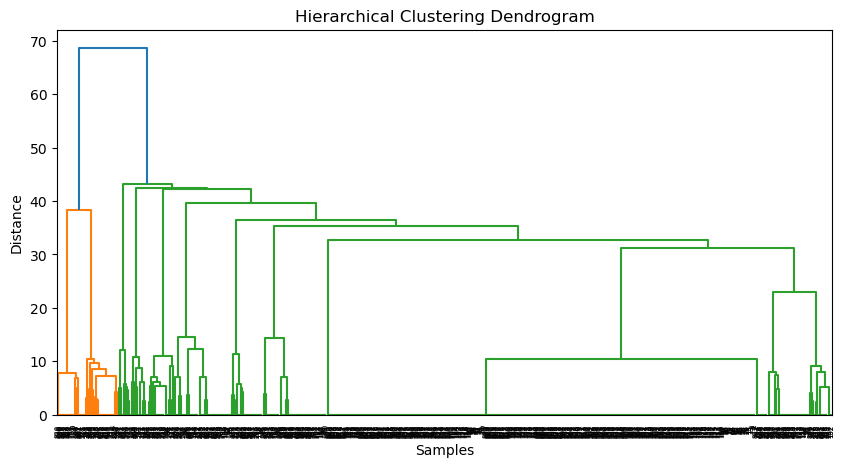

In [24]:
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [25]:
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

In [26]:
df["Agglomerative_Cluster"] = agglo_labels
print("Agglomerative Cluster Column Added.")

Agglomerative Cluster Column Added.


In [30]:
print("KMeans Cluster Counts:")
print(df["KMeans_Cluster"].value_counts())

KMeans Cluster Counts:
KMeans_Cluster
1    823
0     37
2     29
Name: count, dtype: int64


In [29]:
print("Agglomerative Cluster Counts:")
print(df["Agglomerative_Cluster"].value_counts())

Agglomerative Cluster Counts:
Agglomerative_Cluster
0    803
1     70
2     16
Name: count, dtype: int64


In [31]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)

In [32]:
print("Silhouette Score (KMeans):", kmeans_silhouette)
print("Silhouette Score (Agglomerative):", agglo_silhouette)

Silhouette Score (KMeans): 0.520763985560248
Silhouette Score (Agglomerative): 0.5638159840124102
